# SVM Classification with Hyperparameter Tuning (Diabetes)

This notebook loads the Diabetes dataset, creates a `polluted` version (adds noise/missingness),
trains an SVM with hyperparameter tuning using `GridSearchCV`, and compares results between the
clean and polluted datasets.

In [1]:
# (Optional) install dependencies if not present
# Uncomment and run if needed:
# !pip install pandas scikit-learn joblib

In [2]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

# Ensure deterministic behavior
RANDOM_STATE = 42

# Path to dataset (robust: try a few candidate locations and pick the first that exists)
candidates = [
    os.path.join(os.getcwd(), 'Exp_5', 'diabetes.csv'),
    os.path.join(os.getcwd(), 'diabetes.csv'),
    os.path.join(os.path.dirname(os.getcwd()), 'Exp_5', 'diabetes.csv')
]
DATA_PATH = None
for p in candidates:
    if os.path.exists(p):
        DATA_PATH = p
        break
if DATA_PATH is None:
    raise FileNotFoundError(f'Diabetes CSV not found in candidates: {candidates}. Current cwd={os.getcwd()}')
print('Dataset path:', DATA_PATH)

Dataset path: C:\Users\heram\Desktop\MLDL_EXP\Exp_5\diabetes.csv


In [3]:
# Load and inspect data
df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)
display(df.head())
print('Target distribution:')
print(df['Outcome'].value_counts(normalize=True))

Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Target distribution:
Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64


## Create a polluted dataset
We will create a polluted version by: adding Gaussian noise to a random subset of numeric features,
and introducing some missing values. This simulates measurement noise and data corruption.

In [4]:
def create_polluted(df, noise_frac=0.1, nan_frac=0.05, noise_scale=0.1, random_state=RANDOM_STATE):
    np.random.seed(random_state)
    polluted = df.copy(deep=True)
    numeric_cols = polluted.select_dtypes(include=[np.number]).columns.drop('Outcome')
    n_rows = polluted.shape[0]
    # ensure numeric columns are float so we can assign NaN/noisy values safely
    polluted[numeric_cols] = polluted[numeric_cols].astype(float)
    # Add gaussian noise to a fraction of entries in numeric columns
    for col in numeric_cols:
        mask = np.random.rand(n_rows) < noise_frac
        if mask.any():
            col_std = polluted.loc[~polluted[col].isna(), col].std() if polluted[col].notna().any() else 0.0
            noise = np.random.normal(loc=0.0, scale=noise_scale * (col_std if col_std>0 else 1.0), size=mask.sum())
            polluted.loc[mask, col] = polluted.loc[mask, col].values + noise
    # Introduce NaNs at random positions (excluding target)
    for col in numeric_cols:
        mask = np.random.rand(n_rows) < nan_frac
        polluted.loc[mask, col] = np.nan
    return polluted

polluted_df = create_polluted(df, noise_frac=0.12, nan_frac=0.06, noise_scale=0.15)
print('Polluted shape:', polluted_df.shape)
display(polluted_df.head())
print('Num missing values per column in polluted data:')
print(polluted_df.isna().sum())

Polluted shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6.0,148.0,67.332657,NaN,0.0,33.6,0.627,NaN,1
1,1.0,85.0,63.785527,29.000000,0.0,26.6,0.351,31.000000,0
2,8.0,183.0,64.000000,0.000000,0.0,23.3,NaN,32.000000,1
3,1.0,89.0,63.766894,24.496736,94.0,28.1,0.167,21.838561,0
4,0.0,137.0,37.271113,37.118211,168.0,43.1,2.288,33.000000,1


Num missing values per column in polluted data:
Pregnancies                 48
Glucose                     49
BloodPressure               39
SkinThickness               57
Insulin                     40
BMI                         51
DiabetesPedigreeFunction    41
Age                         52
Outcome                      0
dtype: int64


## Training and tuning functions
We'll define a helper that fills missing values (median), scales features, runs GridSearchCV on an SVM pipeline,
and returns evaluation metrics and the best estimator.

In [5]:
from sklearn.impute import SimpleImputer

def train_and_evaluate(df, target='Outcome', test_size=0.2, random_state=RANDOM_STATE, n_jobs=-1, verbose=0):
    X = df.drop(columns=[target])
    y = df[target]

    # Simple imputation then scaling + SVC in pipeline
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('svc', SVC())
    ])

    param_grid = [
        {'svc__kernel': ['linear'], 'svc__C': [0.01, 0.1, 1, 10]},
        {'svc__kernel': ['rbf'], 'svc__C': [0.1, 1, 10], 'svc__gamma': ['scale', 'auto', 0.01]},
        {'svc__kernel': ['poly'], 'svc__C': [0.1, 1], 'svc__degree': [2, 3]}
    ]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
    gs = GridSearchCV(pipeline, param_grid=param_grid, scoring='accuracy', cv=cv, n_jobs=n_jobs, verbose=verbose)
    gs.fit(X_train, y_train)

    best = gs.best_estimator_
    y_pred = best.predict(X_test)

    results = {
        'best_params': gs.best_params_,
        'best_cv_score': gs.best_score_,
        'test_accuracy': accuracy_score(y_test, y_pred),
        'classification_report': classification_report(y_test, y_pred, zero_division=0),
        'confusion_matrix': confusion_matrix(y_test, y_pred),
        'estimator': best
    }
    return results

## Run on clean data
Train/tune the SVM on the original dataset and show results.

In [6]:
print('Training on clean data...')
clean_results = train_and_evaluate(df, n_jobs=-1, verbose=1)
print('Best params (clean):', clean_results['best_params'])
print('CV score (clean):', clean_results['best_cv_score'])
print('Test accuracy (clean):', clean_results['test_accuracy'])
print('\nClassification report (clean):')
print(clean_results['classification_report'])

Training on clean data...
Fitting 5 folds for each of 17 candidates, totalling 85 fits


Best params (clean): {'svc__C': 1, 'svc__kernel': 'linear'}
CV score (clean): 0.7898573903771825
Test accuracy (clean): 0.7207792207792207

Classification report (clean):
              precision    recall  f1-score   support

           0       0.76      0.83      0.79       100
           1       0.62      0.52      0.57        54

    accuracy                           0.72       154
   macro avg       0.69      0.67      0.68       154
weighted avg       0.71      0.72      0.71       154



## Run on polluted data
Train/tune the SVM on the polluted dataset and compare results to the clean run.

In [7]:
print('Training on polluted data...')
polluted_results = train_and_evaluate(polluted_df, n_jobs=-1, verbose=1)
print('\nBest params (polluted):', polluted_results['best_params'])
print('CV score (polluted):', polluted_results['best_cv_score'])
print('Test accuracy (polluted):', polluted_results['test_accuracy'])
print('\nClassification report (polluted):')
print(polluted_results['classification_report'])

Training on polluted data...
Fitting 5 folds for each of 17 candidates, totalling 85 fits



Best params (polluted): {'svc__C': 10, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}
CV score (polluted): 0.7785019325603093
Test accuracy (polluted): 0.7142857142857143

Classification report (polluted):
              precision    recall  f1-score   support

           0       0.75      0.85      0.79       100
           1       0.62      0.46      0.53        54

    accuracy                           0.71       154
   macro avg       0.69      0.66      0.66       154
weighted avg       0.70      0.71      0.70       154



## Save best models and compare
Save the best estimators for later inspection and show a concise comparison.

In [8]:
out_dir = os.path.join(os.getcwd(), 'Exp_5', 'models')
os.makedirs(out_dir, exist_ok=True)
clean_model_path = os.path.join(out_dir, 'svm_clean.joblib')
polluted_model_path = os.path.join(out_dir, 'svm_polluted.joblib')
joblib.dump(clean_results['estimator'], clean_model_path)
joblib.dump(polluted_results['estimator'], polluted_model_path)
print('Saved models to', out_dir)
print('\nSummary comparison:')
print('Clean test accuracy:', clean_results['test_accuracy'])
print('Polluted test accuracy:', polluted_results['test_accuracy'])

Saved models to C:\Users\heram\Desktop\MLDL_EXP\Exp_5\Exp_5\models

Summary comparison:
Clean test accuracy: 0.7207792207792207
Polluted test accuracy: 0.7142857142857143


## Visualizations and Comparisons
Create confusion matrices, accuracy plots, and ROC curves to compare clean vs polluted results.

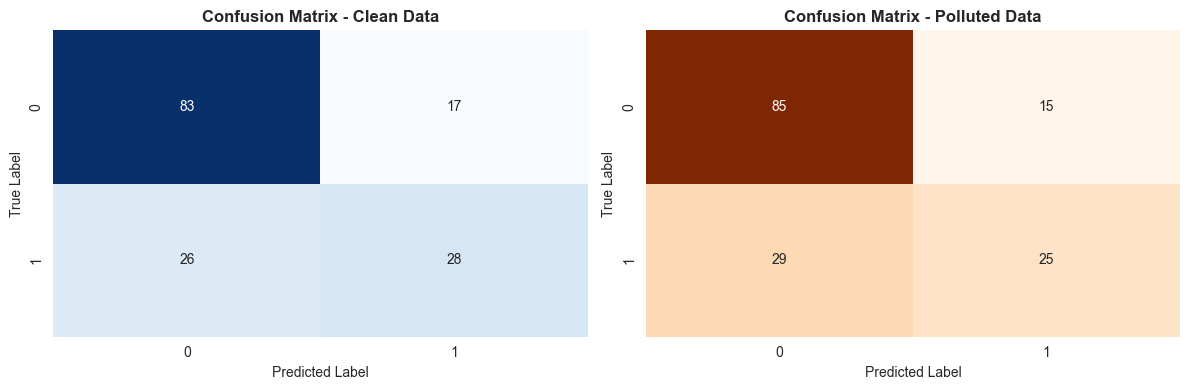

Confusion matrices plotted successfully!


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 5)

# Re-run predictions on test sets for visualization
X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    df.drop(columns=['Outcome']), df['Outcome'], 
    test_size=0.2, random_state=RANDOM_STATE, stratify=df['Outcome']
)
y_pred_clean = clean_results['estimator'].predict(X_test_clean)

X_train_polluted, X_test_polluted, y_train_polluted, y_test_polluted = train_test_split(
    polluted_df.drop(columns=['Outcome']), polluted_df['Outcome'], 
    test_size=0.2, random_state=RANDOM_STATE, stratify=polluted_df['Outcome']
)
y_pred_polluted = polluted_results['estimator'].predict(X_test_polluted)

# Plot confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm_clean = confusion_matrix(y_test_clean, y_pred_clean)
sns.heatmap(cm_clean, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Confusion Matrix - Clean Data', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

cm_polluted = confusion_matrix(y_test_polluted, y_pred_polluted)
sns.heatmap(cm_polluted, annot=True, fmt='d', cmap='Oranges', ax=axes[1], cbar=False)
axes[1].set_title('Confusion Matrix - Polluted Data', fontsize=12, fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

print('Confusion matrices plotted successfully!')

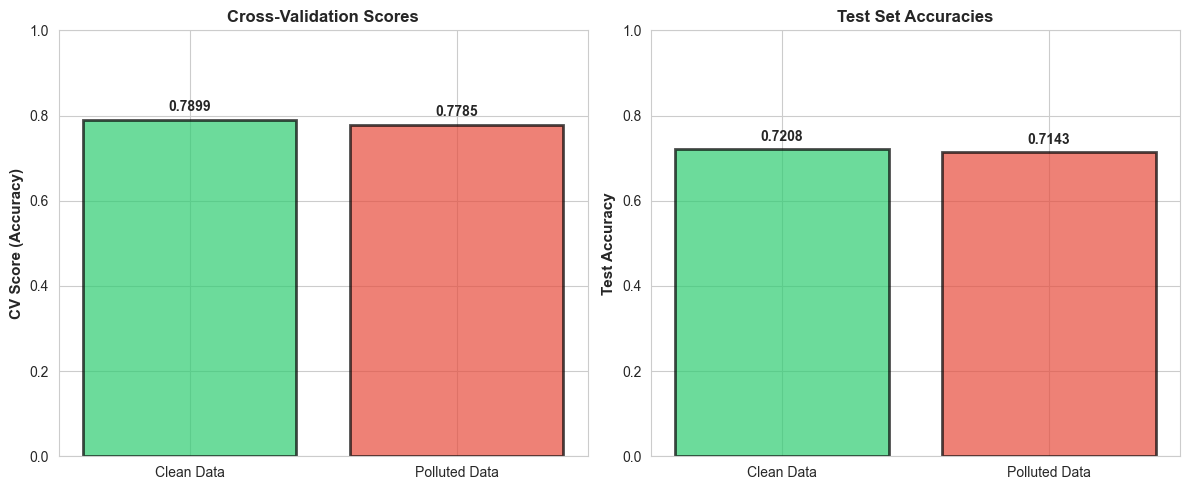


Accuracy Drop (Clean → Polluted): 0.65%


In [10]:
# Accuracy comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# CV Scores
cv_scores = [clean_results['best_cv_score'], polluted_results['best_cv_score']]
categories = ['Clean Data', 'Polluted Data']
colors = ['#2ecc71', '#e74c3c']

axes[0].bar(categories, cv_scores, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
axes[0].set_ylabel('CV Score (Accuracy)', fontsize=11, fontweight='bold')
axes[0].set_title('Cross-Validation Scores', fontsize=12, fontweight='bold')
axes[0].set_ylim([0, 1])
for i, v in enumerate(cv_scores):
    axes[0].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')

# Test Accuracies
test_accs = [clean_results['test_accuracy'], polluted_results['test_accuracy']]
axes[1].bar(categories, test_accs, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
axes[1].set_ylabel('Test Accuracy', fontsize=11, fontweight='bold')
axes[1].set_title('Test Set Accuracies', fontsize=12, fontweight='bold')
axes[1].set_ylim([0, 1])
for i, v in enumerate(test_accs):
    axes[1].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'\nAccuracy Drop (Clean → Polluted): {(clean_results["test_accuracy"] - polluted_results["test_accuracy"])*100:.2f}%')

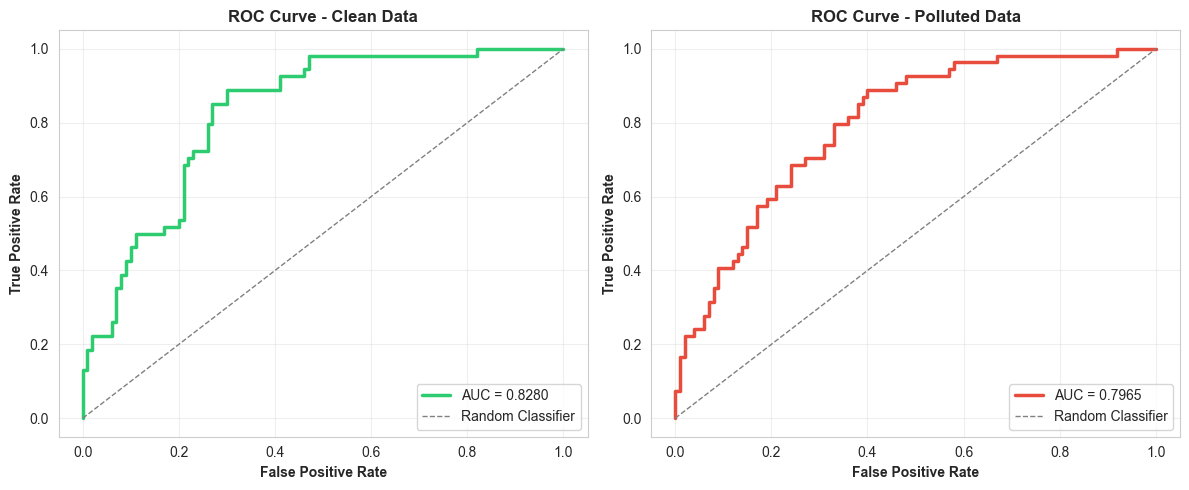

AUC Score - Clean: 0.8280
AUC Score - Polluted: 0.7965


In [11]:
# ROC Curves comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Clean data ROC
y_pred_proba_clean = clean_results['estimator'].decision_function(X_test_clean)
fpr_clean, tpr_clean, _ = roc_curve(y_test_clean, y_pred_proba_clean)
roc_auc_clean = auc(fpr_clean, tpr_clean)

axes[0].plot(fpr_clean, tpr_clean, color='#2ecc71', lw=2.5, label=f'AUC = {roc_auc_clean:.4f}')
axes[0].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier')
axes[0].set_xlabel('False Positive Rate', fontweight='bold')
axes[0].set_ylabel('True Positive Rate', fontweight='bold')
axes[0].set_title('ROC Curve - Clean Data', fontsize=12, fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# Polluted data ROC
y_pred_proba_polluted = polluted_results['estimator'].decision_function(X_test_polluted)
fpr_polluted, tpr_polluted, _ = roc_curve(y_test_polluted, y_pred_proba_polluted)
roc_auc_polluted = auc(fpr_polluted, tpr_polluted)

axes[1].plot(fpr_polluted, tpr_polluted, color='#e74c3c', lw=2.5, label=f'AUC = {roc_auc_polluted:.4f}')
axes[1].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier')
axes[1].set_xlabel('False Positive Rate', fontweight='bold')
axes[1].set_ylabel('True Positive Rate', fontweight='bold')
axes[1].set_title('ROC Curve - Polluted Data', fontsize=12, fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'AUC Score - Clean: {roc_auc_clean:.4f}')
print(f'AUC Score - Polluted: {roc_auc_polluted:.4f}')

In [12]:
# Summary comparison table
import pandas as pd

summary_df = pd.DataFrame({
    'Metric': ['Best Kernel', 'Best C', 'Best Gamma/Degree', 'CV Score', 'Test Accuracy'],
    'Clean Data': [
        clean_results['best_params'].get('svc__kernel', 'N/A'),
        clean_results['best_params'].get('svc__C', 'N/A'),
        clean_results['best_params'].get('svc__gamma', clean_results['best_params'].get('svc__degree', 'N/A')),
        f"{clean_results['best_cv_score']:.4f}",
        f"{clean_results['test_accuracy']:.4f}"
    ],
    'Polluted Data': [
        polluted_results['best_params'].get('svc__kernel', 'N/A'),
        polluted_results['best_params'].get('svc__C', 'N/A'),
        polluted_results['best_params'].get('svc__gamma', polluted_results['best_params'].get('svc__degree', 'N/A')),
        f"{polluted_results['best_cv_score']:.4f}",
        f"{polluted_results['test_accuracy']:.4f}"
    ]
})

print('\n=== COMPREHENSIVE SUMMARY ===')
print(summary_df.to_string(index=False))
print(f'\nAccuracy Degradation: {(clean_results["test_accuracy"] - polluted_results["test_accuracy"])*100:.2f}%')
print(f'Models saved to: Exp_5/models/')


=== COMPREHENSIVE SUMMARY ===
           Metric Clean Data Polluted Data
      Best Kernel     linear           rbf
           Best C          1            10
Best Gamma/Degree        N/A          0.01
         CV Score     0.7899        0.7785
    Test Accuracy     0.7208        0.7143

Accuracy Degradation: 0.65%
Models saved to: Exp_5/models/


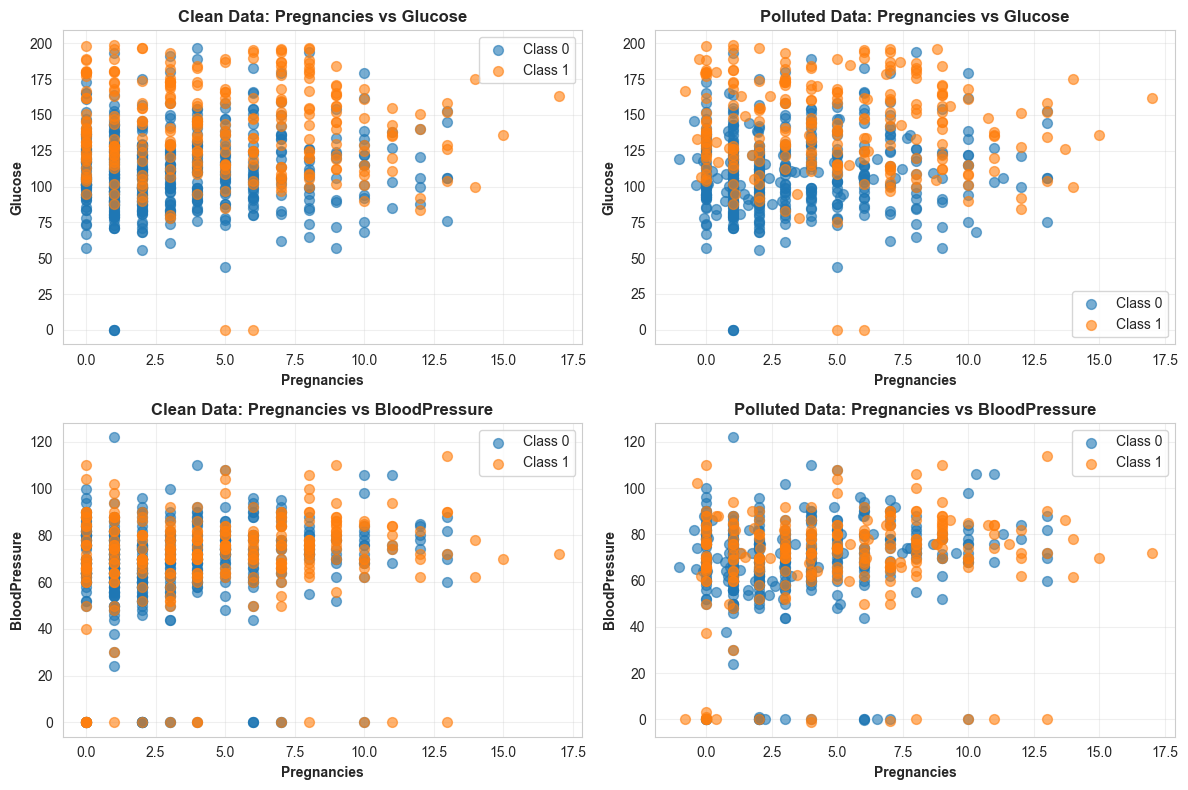

Data distributions plotted - showing the pollution effect on feature space


In [13]:
# Data pollution effect visualization
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Clean data - first two features
sample_cols = ['Glucose', 'BloodPressure']
for idx, col in enumerate(sample_cols[:2]):
    ax = axes[idx, 0]
    for outcome in [0, 1]:
        mask = df['Outcome'] == outcome
        ax.scatter(df.loc[mask, 'Pregnancies'], df.loc[mask, col], 
                  alpha=0.6, s=50, label=f'Class {outcome}')
    ax.set_xlabel('Pregnancies', fontweight='bold')
    ax.set_ylabel(col, fontweight='bold')
    ax.set_title(f'Clean Data: Pregnancies vs {col}', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

# Polluted data - same features
for idx, col in enumerate(sample_cols[:2]):
    ax = axes[idx, 1]
    for outcome in [0, 1]:
        mask = polluted_df['Outcome'] == outcome
        ax.scatter(polluted_df.loc[mask, 'Pregnancies'], polluted_df.loc[mask, col], 
                  alpha=0.6, s=50, label=f'Class {outcome}')
    ax.set_xlabel('Pregnancies', fontweight='bold')
    ax.set_ylabel(col, fontweight='bold')
    ax.set_title(f'Polluted Data: Pregnancies vs {col}', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('Data distributions plotted - showing the pollution effect on feature space')